# Final Results Comparison

In [2]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Comparison Configuration
# Set a professional style for plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.4)

# Paths
RESULTS_PATH = "../results/"
SINGLE_TRAJ_PATH = os.path.join(RESULTS_PATH, "single_trajectory")
TRIPLE_TRAJ_PATH = os.path.join(RESULTS_PATH, "triple_trajectory")

# Check if paths exist
if not os.path.exists(SINGLE_TRAJ_PATH) or not os.path.exists(TRIPLE_TRAJ_PATH):
    print("Warning: Results directories not found. Please run optimizations first.")
else:
    print("Results directories found.")

# Color Palette for Algorithms
# Consistent colors across all plots
COLORS = {
    "ACO-R (Base)": "#ff7f0e",       # Orange
    "ACO-R + LS (Hybrid)": "#2ca02c",  # Green
    "Binary GA": "#d62728",          # Red
    "Target": "#1f77b4"              # Blue
}

Results directories found.


In [8]:
# Load DataFrames
try:
    # Performance Metrics
    perf_single = pd.read_csv(os.path.join(SINGLE_TRAJ_PATH, "final_performance_single.csv"))
    # Note: checking typical naming convention from previous steps (summary_performance vs final_performance_triple)
    # We try to load what you requested
    perf_triple = pd.read_csv(os.path.join(TRIPLE_TRAJ_PATH, "final_performance_triple.csv")) 

    # Parameters
    params_single = pd.read_csv(os.path.join(SINGLE_TRAJ_PATH, "single_trajectory_parameters.csv"))
    params_triple = pd.read_csv(os.path.join(TRIPLE_TRAJ_PATH, "triple_trajectory_parameters.csv"))

    print("All datasets loaded successfully.")
    
    # Display preview
    print("\n--- Single Trajectory Performance ---")
    display(perf_single.head())
    print("\n--- Triple Trajectory Performance ---")
    display(perf_triple.head())

except FileNotFoundError as e:
    print(f"Error loading files: {e}")
    print("Please check file names in ../results/ folder.")

All datasets loaded successfully.

--- Single Trajectory Performance ---


,Algorithm,Exec Time (s),Best Fitness,Range Err (m),Apogee Err (m),TOF Err (s),TBO Err (s)
0,ACO-R (Base),449.603101,0.465114,0.801772,1.730527,0.128379,0.133548
1,ACO-R + LS (Hybrid),573.902125,0.192412,0.000241,0.000272,0.134419,0.107987
2,Binary GA,1070.899308,0.849071,0.076504,0.139148,0.330647,0.546906



--- Triple Trajectory Performance ---


,Algorithm,Total Fitness,Exec Time (s),Avg Range Err (m),Avg Apogee Err (m),Avg TOF Err (s),Avg TBO Err (s)
0,ACO-R (Base),0.694840,1167.737284,1.321111,0.287187,0.051816,0.050965
1,ACO-R + LS (Hybrid),0.647997,1469.617284,1.217992,0.208594,0.052667,0.049416
2,Binary GA,1.214899,4366.490271,1.163535,0.484923,0.080155,0.125406


/tmp/ipykernel_28440/1762044569.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Algorithm', y='Exec Time (s)', data=df, ax=axes[0], palette=colors)
/tmp/ipykernel_28440/1762044569.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Algorithm', y='Total Fitness' if 'Total Fitness' in df.columns else 'Best Fitness',


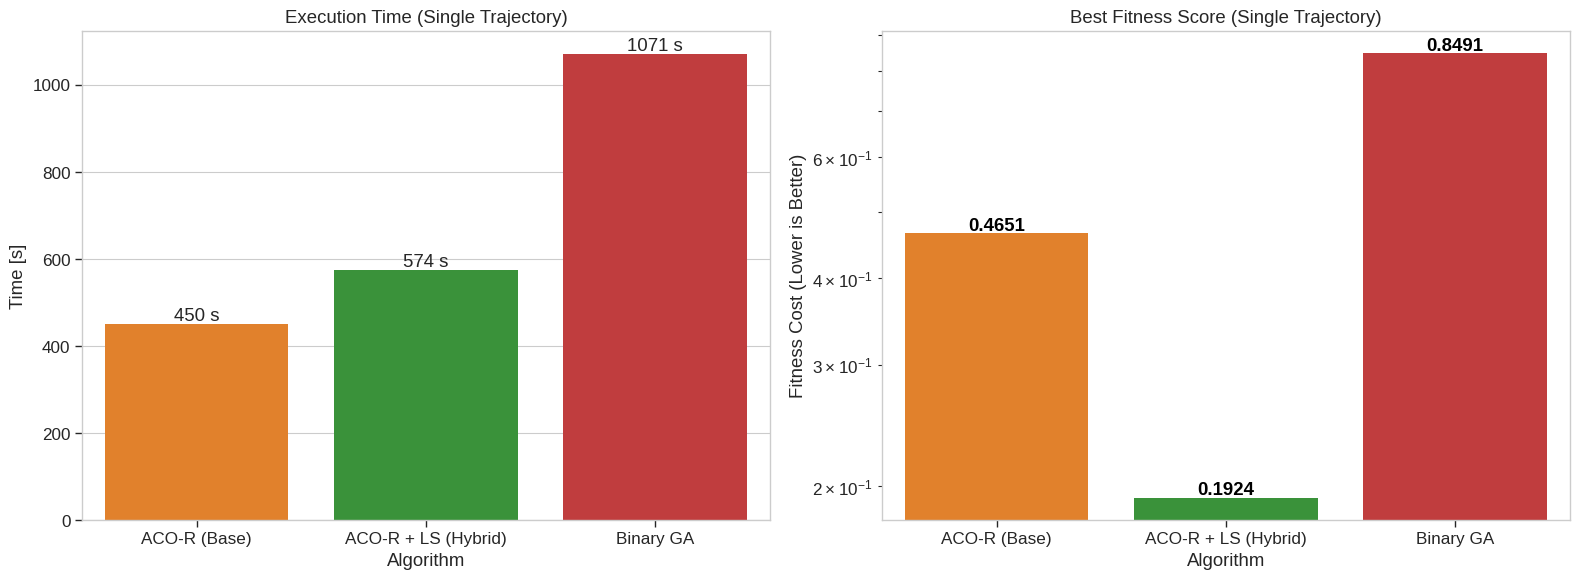

/tmp/ipykernel_28440/1762044569.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Algorithm', y='Exec Time (s)', data=df, ax=axes[0], palette=colors)
/tmp/ipykernel_28440/1762044569.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Algorithm', y='Total Fitness' if 'Total Fitness' in df.columns else 'Best Fitness',


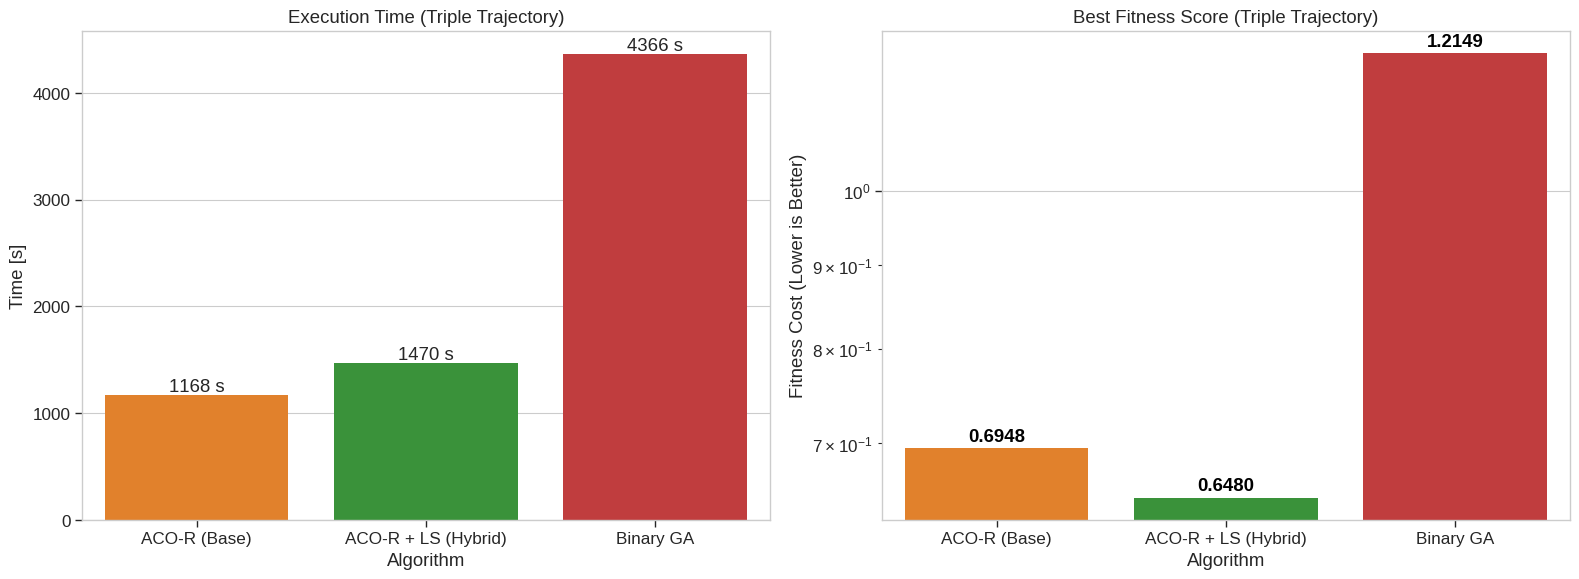

In [13]:
def plot_performance_comparison(df, title_suffix):
    """Helper function to plot Fitness and Time side-by-side"""
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Algorithms
    algs = df['Algorithm']
    colors = [COLORS.get(a, 'gray') for a in algs]
    
    # 1. Execution Time
    sns.barplot(x='Algorithm', y='Exec Time (s)', data=df, ax=axes[0], palette=colors)
    axes[0].set_title(f"Execution Time ({title_suffix})")
    axes[0].set_ylabel("Time [s]")
    for container in axes[0].containers:
        axes[0].bar_label(container, fmt='%.0f s')

    # 2. Best Fitness (Log Scale)
    sns.barplot(x='Algorithm', y='Total Fitness' if 'Total Fitness' in df.columns else 'Best Fitness', 
                data=df, ax=axes[1], palette=colors)
    axes[1].set_title(f"Best Fitness Score ({title_suffix})")
    axes[1].set_ylabel("Fitness Cost (Lower is Better)")
    axes[1].set_yscale("log") # Log scale is crucial here
    
    # Add values on top
    for i, v in enumerate(df['Total Fitness'] if 'Total Fitness' in df.columns else df['Best Fitness']):
        axes[1].text(i, v * 1.01, f"{v:.4f}", ha='center', color='black', fontweight='bold')

    plt.tight_layout()
    plt.show()

# Generate Plots
plot_performance_comparison(perf_single, "Single Trajectory")
plot_performance_comparison(perf_triple, "Triple Trajectory")

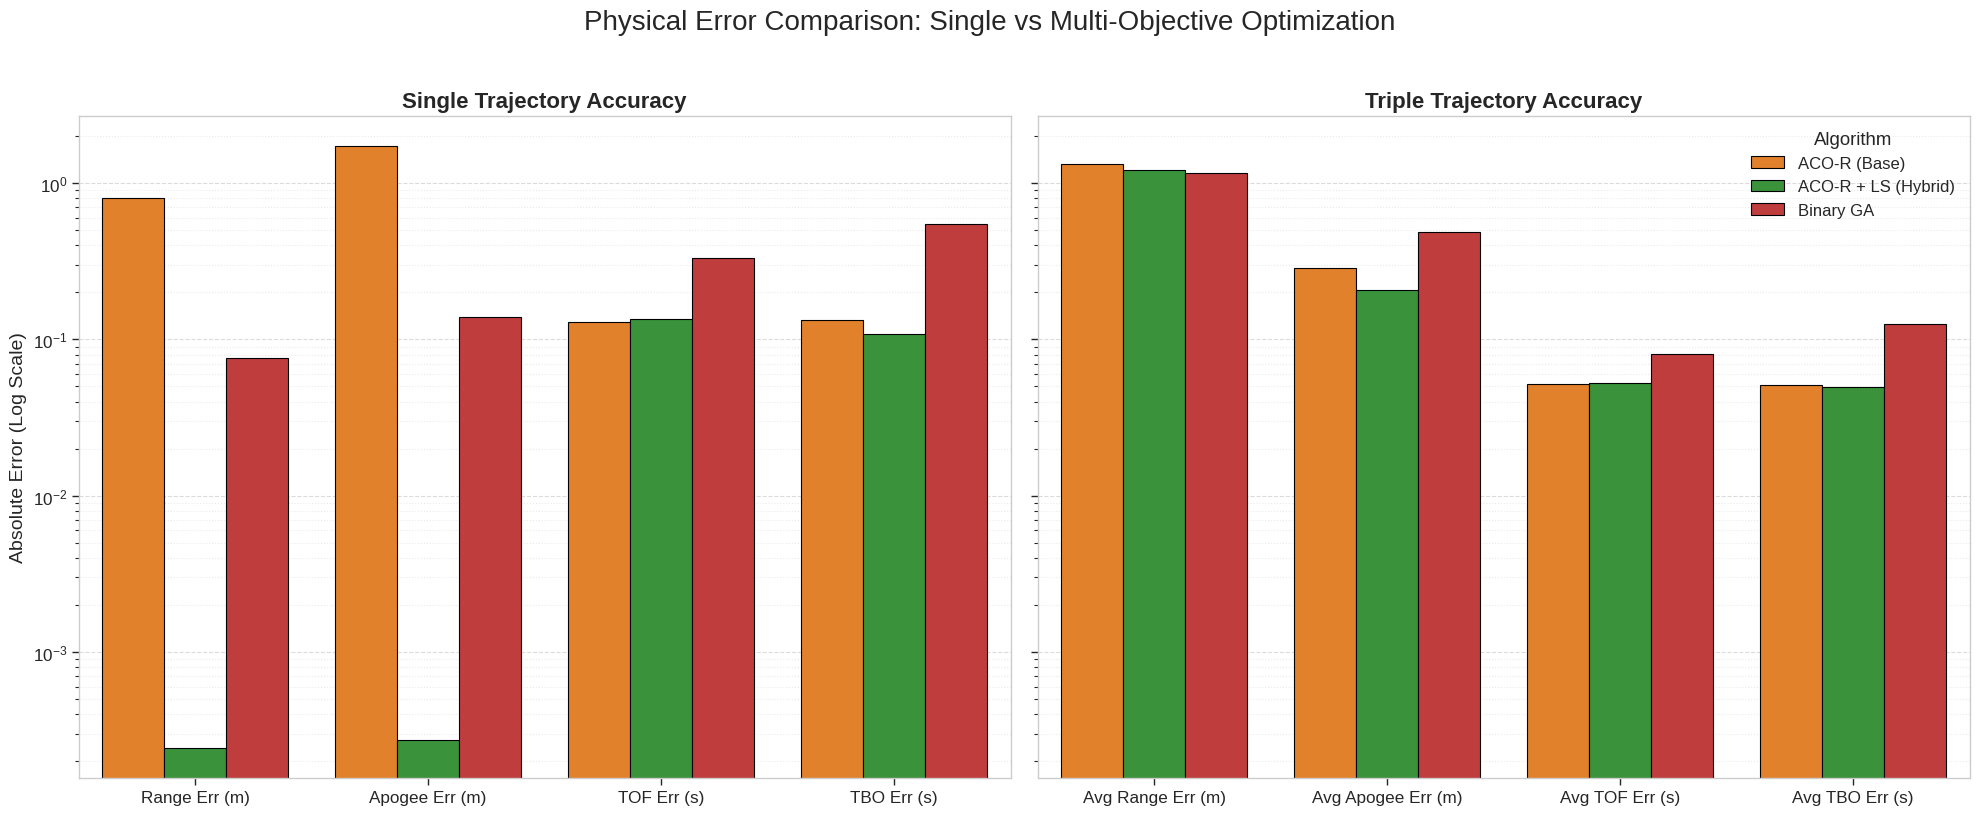

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_physical_errors_comparison(df_single, df_triple):
    """
    Plots Range, Apogee, TOF, TBO errors for both tasks side-by-side
    sharing the same Y-axis scale.
    """
    
    # --- 1. Data Preparation (Melt) ---
    # Single Trajectory
    error_cols_s = [c for c in df_single.columns if 'Err' in c]
    df_melted_s = df_single.melt(id_vars="Algorithm", value_vars=error_cols_s, 
                                 var_name="Metric", value_name="Error")
    
    # Triple Trajectory
    error_cols_t = [c for c in df_triple.columns if 'Err' in c]
    df_melted_t = df_triple.melt(id_vars="Algorithm", value_vars=error_cols_t, 
                                 var_name="Metric", value_name="Error")

    # --- 2. Setup Figure with Shared Y-Axis ---
    fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharey=True)
    
    # --- 3. Plotting ---
    
    # Subplot 1: Single Trajectory
    sns.barplot(data=df_melted_s, x="Metric", y="Error", hue="Algorithm", 
                palette=COLORS, edgecolor="black", ax=axes[0])
    axes[0].set_title("Single Trajectory Accuracy", fontsize=16, fontweight='bold')
    axes[0].set_xlabel("")
    axes[0].set_ylabel("Absolute Error (Log Scale)", fontsize=14)
    axes[0].grid(True, which="major", axis='y', linestyle='--', alpha=0.7)
    axes[0].grid(True, which="minor", axis='y', linestyle=':', alpha=0.4)
    
    # Subplot 2: Triple Trajectory
    sns.barplot(data=df_melted_t, x="Metric", y="Error", hue="Algorithm", 
                palette=COLORS, edgecolor="black", ax=axes[1])
    axes[1].set_title("Triple Trajectory Accuracy", fontsize=16, fontweight='bold')
    axes[1].set_xlabel("")
    axes[1].set_ylabel("") # Hide label as it is shared
    axes[1].grid(True, which="major", axis='y', linestyle='--', alpha=0.7)
    axes[1].grid(True, which="minor", axis='y', linestyle=':', alpha=0.4)

    # --- 4. Global Formatting ---
    
    # Apply Log Scale to the shared Y-axis
    axes[0].set_yscale("log")
    
    # Handle Legend (Remove duplicate from second plot, keep one unified)
    axes[0].get_legend().remove()
    axes[1].legend(loc='upper right', fontsize=12, title="Algorithm")
    
    # Add a super title
    fig.suptitle("Physical Error Comparison: Single vs Multi-Objective Optimization", fontsize=20, y=1.02)
    
    plt.tight_layout()
    plt.show()

# Execute
plot_physical_errors_comparison(perf_single, perf_triple)

In [18]:
import pandas as pd
import os

# ==============================================================================
# FINAL FITNESS COMPARISON TABLE (MERGED)
# ==============================================================================

# 1. Define Paths to Results
base_path = "../results"
single_path = os.path.join(base_path, "single_trajectory", "final_performance_single.csv")
triple_path = os.path.join(base_path, "triple_trajectory", "final_performance_triple.csv")

try:
    # 2. Load Dataframes
    df_single = pd.read_csv(single_path)
    df_triple = pd.read_csv(triple_path)

    # 3. Extract and Rename Columns for Clarity
    # Single: Algorithm, Best Fitness -> Algorithm, Single Trajectory Fitness
    df_s_clean = df_single[['Algorithm', 'Best Fitness']].copy()
    df_s_clean.rename(columns={'Best Fitness': 'Single Trajectory'}, inplace=True)

    # Triple: Algorithm, Total Fitness -> Algorithm, Triple Trajectory Fitness
    df_t_clean = df_triple[['Algorithm', 'Total Fitness']].copy()
    df_t_clean.rename(columns={'Total Fitness': 'Triple Trajectory'}, inplace=True)

    # 4. Merge Dataframes on 'Algorithm'
    # This creates the requested structure: Algorithm | Single | Triple
    df_merged = pd.merge(df_s_clean, df_t_clean, on='Algorithm', how='inner')

    # 5. Formatting and Display
    pd.options.display.float_format = '{:,.4f}'.format

    print("\n" + "="*60)
    print("FINAL FITNESS SUMMARY: SINGLE VS TRIPLE TRAJECTORY")
    print("="*60)
    
    # Optional: Set Algorithm as index for cleaner display
    df_merged.set_index('Algorithm', inplace=True)
    
    display(df_merged)

    # 6. Export to CSV
    output_path = os.path.join(base_path, "global_fitness_comparison.csv")
    df_merged.to_csv(output_path)
    print(f"\nSummary saved to: {output_path}")

except FileNotFoundError as e:
    print(f"Error: Could not load result files. Make sure you have run both optimization notebooks.\nDetails: {e}")


FINAL FITNESS SUMMARY: SINGLE VS TRIPLE TRAJECTORY


,Single Trajectory,Triple Trajectory
Algorithm,,
ACO-R (Base),0.4651,0.6948
ACO-R + LS (Hybrid),0.1924,0.6480
Binary GA,0.8491,1.2149



Summary saved to: ../results/global_fitness_comparison.csv
